In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly
import math 


# 1. Business Understanding

The purpose of this project is to predict whether an online shopper is likely to complete a purchase based on their browsing behaviour during a website session. By identifying customers with high purchase intention, an online business can provide more relevant product recommendations, promotions or reminders. This may help improve conversion rates, reduce unnecessary marketing costs and create a more personalised shopping experience. my final goal here is i hope to pass out a % or so call a chance of wheather this customer might buy or not buy the items. This is a classification problem and the dataset also is only True/Flase for the target(revenue) but the result still can be displayed as %. This is still a binary classification problem because the target contains two categories True/False(purchase and non-purchase).The probability percentage provides more detail about the strength of the prediction, but it does not change the problem into regression.

# 2. Data Understanding

Before anything could start we have to know why use this dataset and if it is save to use(what makes a good datasets)
So here i am using a data set from link:https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset and it is call Online Shoppers Purchasing Intention Dataset. and i will be giving edvidence on why this dataset is good or safe to use

1) it is hosted by the official UCI Machine Learning Repository
2) it has the creator C.Sakar and Yomi Kastro's names 
3) it has permanent DOI which let people locate the official datasets 
4) it is linked to a published research paper (extemly imporant) Springer’s    Neural Computing and Applications, volume 31, pages 6893–6908.
5) the data collection was well explained 
6) each featurs is well explain and it tells why it might affect results 
7) it has a legal licence 
   -Creative Commons Attribution 4.0 International
   -CC BY 4.0

## 2.1 Load dataset

In [ ]:
# just getting the data and have a look frist 
FILE_PATH = "online_shoppers_intention.csv"
df = pd.read_csv(FILE_PATH) 
df 

# this is a copy of the dataset this allow us to check and compare at anypoint of the project 
copy_df = df.copy()

# what are these colunms ?
#Administrative: the number of pages the user visit 
#Administrative_Duration: time spent(s) on the page
#Informational: The number of pages the user visited to read about the company (e.g. about us, contact pages, or privacy policies).
#Informational_Duration:  time spent on those pages
#ProductRelated: The number of pages the user visited to look at actual items, browse categories, or check product details.
#ProductRelated_Duration: The total time (s) the user spent looking at products.

#BounceRates: The percentage of visitors who entered the website on this page and immediately left
#ExitRates: The percentage of times a specific page was the very last page a user looked at before closing the tab or leaving the website entirely.
#PageValues: Pages that a user visits right before making a purchase get a high score; pages that rarely lead to sales get a zero.

#SpecialDay: A rating from 0.0 to 1.0 showing how close the shopping session is to a major holiday. 1.0 means it's the peak shopping day.
#Month: The month of the year when the session occurred .
#Weekend: A True or False flag showing if the user was shopping on a Saturday or Sunday.

#OperatingSystems: An anonymous ID number representing the software the user's device runs on (e.g., Windows, macOS, Android).
#Browser: An anonymous ID number representing the web browser used (e.g., Chrome, Safari, Firefox).
#Region: representing the geographic location or territory the user is browsing from.
#TrafficType: (e.g., via a Google search, a paid Instagram ad, or typing the link directly).
#VisitorType: Categorizes the user as a New_Visitor, Returning_Visitor, or Other.

# traget: revenue - True/False 

In [ ]:
# get the rows and col 
number_of_rows, number_of_columns = df.shape
print("Number of rows:", number_of_rows)
print("Number of columns:", number_of_columns)


number_of_features = number_of_columns - 1    # -1 as the target is not counted 
row_feature_ratio = number_of_rows / number_of_features

print(f"Approximately {row_feature_ratio:.1f} rows for every feature.")

# informations get:
# the row to feature ratio here tells me how many examples the model get to look at for each features a 752.3 is ok and 
# from out school notes the guid line is that the rows might be 10x of the features so at this point the rows and cols matched it. PASSED
# as i was doing and learning i came back here and drop down this is the data quantity which is ok 

Number of rows: 12330
Number of columns: 18
Approximately 725.3 rows for every feature.


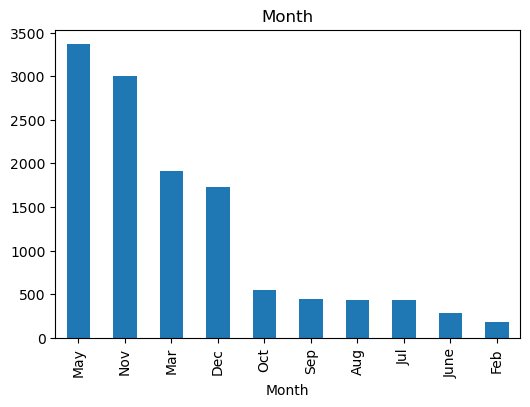

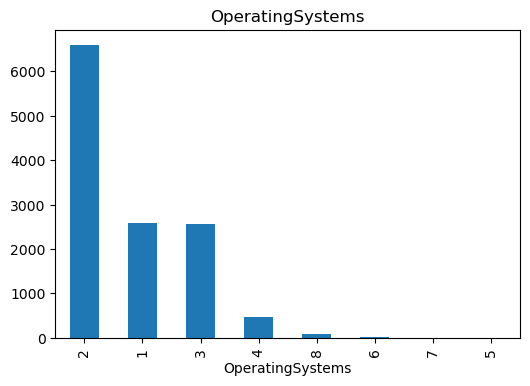

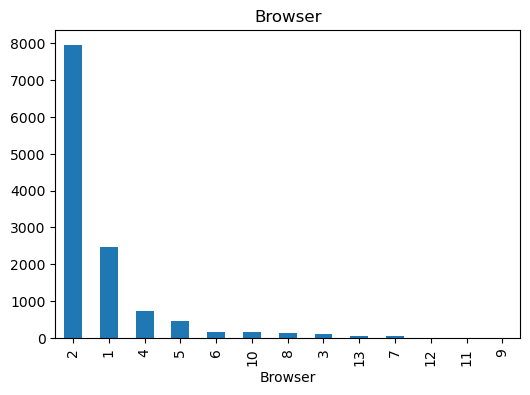

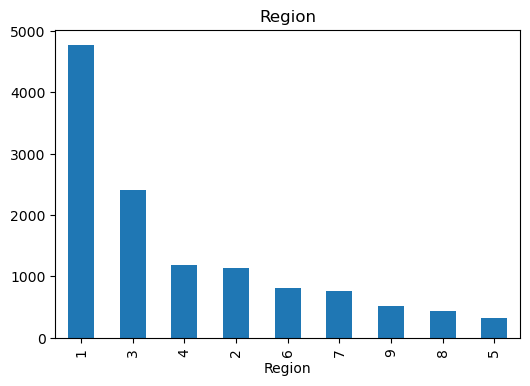

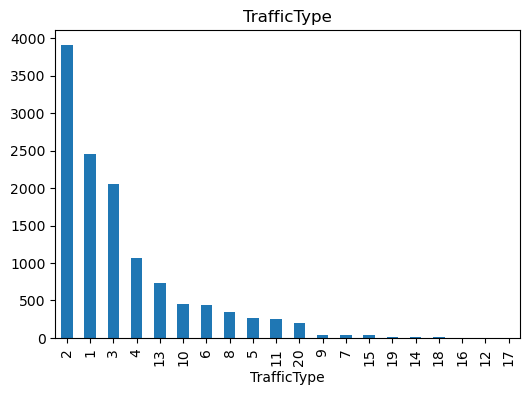

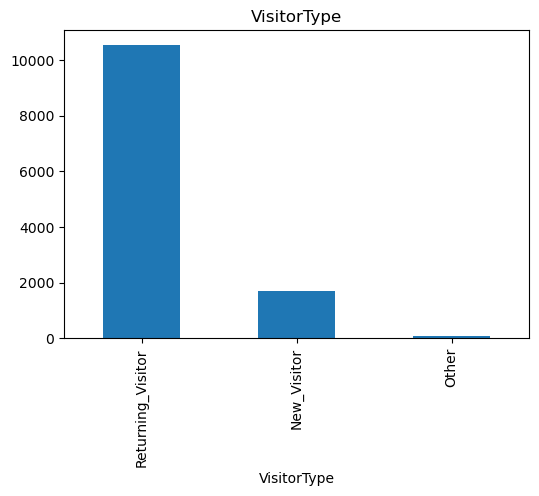

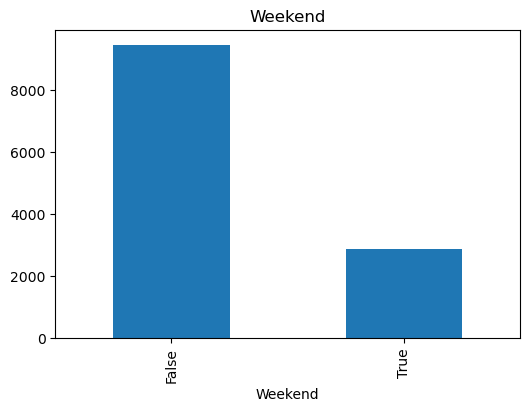

In [ ]:
import matplotlib.pyplot as plt

categorical_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.show()

# this part we are checking the diversity of the dataset 
# at frist this part i was thinking if i should remove the browser col as how can that even affect the target
# but when i think deeper it might have some correclation like safari are i phone user they might shop during 
# leisure time, so we will keep it for now 
# at this point i have done the 4 check: Relevant,quality,quantity and diversity

In [5]:
## Understand the type of variable for each column
data_type_report = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "example_values": [
        df[column].drop_duplicates().head(5).tolist()
        for column in df.columns
    ]
})

display(data_type_report)

#insights we know now:
#1)
#  The OperatingSystems, Browser, Region, and TrafficType.(1, 2, 3, 4), but the data_type is correctly listed as category.
#  this means the machine will not treat them as order but it is a group which is good 
# 2)
#  There is a lot of 0.0 for Administrative	Administrative_Duration	Informational	Informational_Duration 
#  this tells us that normal customer dont go to these page and won't even stay and also how the graph might look like later 
#3)
#  BounceRates, ExitRates, and PageValues are all float64 these are important indicators from the col understanding

# things to do later(not fully but now we at least know some)
#1)Encode Categorical Variables(visitory type,month and weekend) machine learning algorithms only understand numbers using One-Hot Encoding or other endcoing 

,data_type,example_values
Administrative,int64,"[0, 1, 2, 4, 12]"
Administrative_Duration,float64,"[0.0, 53.0, 64.6, 6.0, 18.0]"
Informational,int64,"[0, 1, 2, 4, 16]"
Informational_Duration,float64,"[0.0, 120.0, 16.0, 94.0, 93.0]"
ProductRelated,int64,"[1, 2, 10, 19, 0]"
ProductRelated_Duration,float64,"[0.0, 64.0, 2.666666667, 627.5, 154.2166667]"
BounceRates,float64,"[0.2, 0.0, 0.05, 0.02, 0.015789474]"
ExitRates,float64,"[0.2, 0.1, 0.14, 0.05, 0.024561404]"
PageValues,float64,"[0.0, 54.17976426, 19.44707913, 38.30849268, 2..."
SpecialDay,float64,"[0.0, 0.4, 0.8, 1.0, 0.2]"


In [6]:
## Check for missing data
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
})

missing_report = missing_report.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_report)
# ok this dataset was already told that it has no missing values but it is still important to check 

,missing_count,missing_percentage
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


In [25]:
#outliers

numeric_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]
# print numbers for me to see 
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")


# so from this part i do see that i have outliers and i have to decide which to clear later 


Administrative: 404 outliers
Administrative_Duration: 1149 outliers
Informational: 2631 outliers
Informational_Duration: 2405 outliers
ProductRelated: 1007 outliers
ProductRelated_Duration: 951 outliers
BounceRates: 1428 outliers
ExitRates: 1325 outliers
PageValues: 2730 outliers
SpecialDay: 1249 outliers


In [ ]:
# unique col 
unique_value_report = pd.DataFrame({
    "unique_count": df.nunique(dropna=False),
    "unique_percentage": (
        df.nunique(dropna=False) /
        len(df) * 100
    ),
    "example_values": [
        df[column].drop_duplicates().head(10).tolist()
        for column in df.columns
    ]
})

display(
    unique_value_report.sort_values(
        "unique_count"
    )
)

#insights 
#1)
#Revenue, Weekend, VisitorType, SpecialDay, operatingSystems, 
#Region, Month, Browser, TrafficType These values has such an low unique count
# meaning even if we apply OHE for the col we dont have 
# to worry about curse of dimensionality
#2)Informational has 17 unique values, Administrative has 27, 
# but ProductRelated jumps all the way up to 311 unique values (2.52%).
# this shows not many people go to administrative page since they are here to shope
# This high variation means ProductRelated page have stronger indicator of user intent 
#3)
#Durations (Informational, Administrative, ProductRelated), BounceRates, ExitRates, PageValues
# this just shows that everyone spents different time which is important 

,unique_count,unique_percentage,example_values
Revenue,2,0.016221,"[False, True]"
Weekend,2,0.016221,"[False, True]"
VisitorType,3,0.024331,"[Returning_Visitor, New_Visitor, Other]"
SpecialDay,6,0.048662,"[0.0, 0.4, 0.8, 1.0, 0.2, 0.6]"
OperatingSystems,8,0.064882,"[1, 2, 4, 3, 7, 6, 8, 5]"
Region,9,0.072993,"[1, 9, 2, 3, 4, 5, 6, 7, 8]"
Month,10,0.081103,"[Feb, Mar, May, Oct, June, Jul, Aug, Nov, Sep,..."
Browser,13,0.105434,"[1, 2, 3, 4, 5, 6, 7, 10, 8, 9]"
Informational,17,0.137875,"[0, 1, 2, 4, 16, 5, 3, 14, 6, 12]"
TrafficType,20,0.162206,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"


In [8]:
constant_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) == 1
]

print("Constant columns:", constant_columns)

#Constant columns should normally be removed because:
#They provide no predictive information
#They add unnecessary complexity
#They may interfere with some statistical calculations
#Their variance is zero
# but for this it seems like we dont have this problem for our datasets 

Constant columns: []


In [9]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = df.duplicated().mean() * 100

print("Duplicate rows:", duplicate_count)
print(
    f"Duplicate percentage: "
    f"{duplicate_percentage:.2f}%"
)

# here tells me that i have duplicate rows and i should clear them up later in the data cleaning as it prevents data leakage
# we dw the model to remember the data and become overfitting if they can remember the rows when we split into train test set later 

Duplicate rows: 125
Duplicate percentage: 1.01%


In [ ]:
# inconsistent for catergorical 

for col in categorical_cols:
    print(df[col].unique())

# this seems ok

['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
[1 2 4 3 7 6 8 5]
[ 1  2  3  4  5  6  7 10  8  9 12 13 11]
[1 9 2 3 4 5 6 7 8]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 16 17 20]
['Returning_Visitor' 'New_Visitor' 'Other']
[False  True]


# summary of the bussines and data understanding 

In [ ]:
# 1)so we dfine what we want for the bussiness
# 2)I done the 4 check: Relevant,quality,quantity and diversity making sure they are all ok 
# 3)then I get  to know the types of the datas
# 4) I check for missing which my dataset dont have 
# 5) I check for outliers which have 
# 6) I check for Unique coluns and consant 
# 7) I check for duplicates which also have 
# 8) I check for inconsistent which dont have 

## Steps to do after understanding the data 

In [ ]:
# at this point i have some basic understanding of what my data is and we will start cleaing the dataset 
# but we actually going to performe data cleaning 2 times, frist is before EDA and after EDA to make sure 
# i have a perfectly clean data for me to use later 
# things to clean for this part: duplicates 

df = df.drop_duplicates()
print(f"The number of duplicates left is {df.duplicated().sum()}")

# outliers and the datatypes we will do it after EDA 

The number of duplicates left is 0


## 2.3 EDA

## 2.3.1 basic EDA without visulizations yet 

In [ ]:
## Describe data distribution 
df.describe(include='all')

# it seems like there is no impossible values but 
#1)
# ProductRelated_Duration - 75% of users spend less than 1,464 seconds 24 minutes on product pages,
# but the maximum value is 63,973.5 seconds that is 17.7 hours might be leaving thee page open for too long 
# Administrative_Duration - jumps from a 75% mark of 93 seconds up to a max of 3,398 seconds 56 minutes( he might be checking something).
#2)
# python is treating the OperatingSystems, Browser, Region, and TrafficType as numeric numerbs 
#they have numbers for mean, std, min, and max, while their unique and top rows are NaN
#3)
# there is a imbalance in the revenue which can lead to "Lazy student model" this basically means the model can see that if he spams False 
# the final result he has a 85% chance of getting right which is a high score but he did not learn anything and it is just spamming the answer 
# with a Flase no learning point at all just guessing so accuracy alone is misleading 

# things to do later, clear the outlier,fix the data type(the encoding later),and the lazy student problem 

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205,12205.000000,12205.000000,12205.000000,12205.000000,12205,12205,12205
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3329,NaN,NaN,NaN,NaN,10431,9346,10297
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,NaN,2.124211,2.357804,3.153298,4.073904,NaN,NaN,NaN
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,NaN,0.906823,1.710114,2.402340,4.016654,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


In [ ]:
df.info()

# after applying this i find it a bit useless as we already know all these informations but it's ok we will just keep
# at least it tells us how many of the datatypes are there 

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

## summary for the EDA (no visuliazations)

1) no impossible values
2) handle the datatypes later (encoding)
3) the lazy student problem/ imbalance 
4) outliers will future dive in later 

## 2.3.2 Exploratory Data Analysis

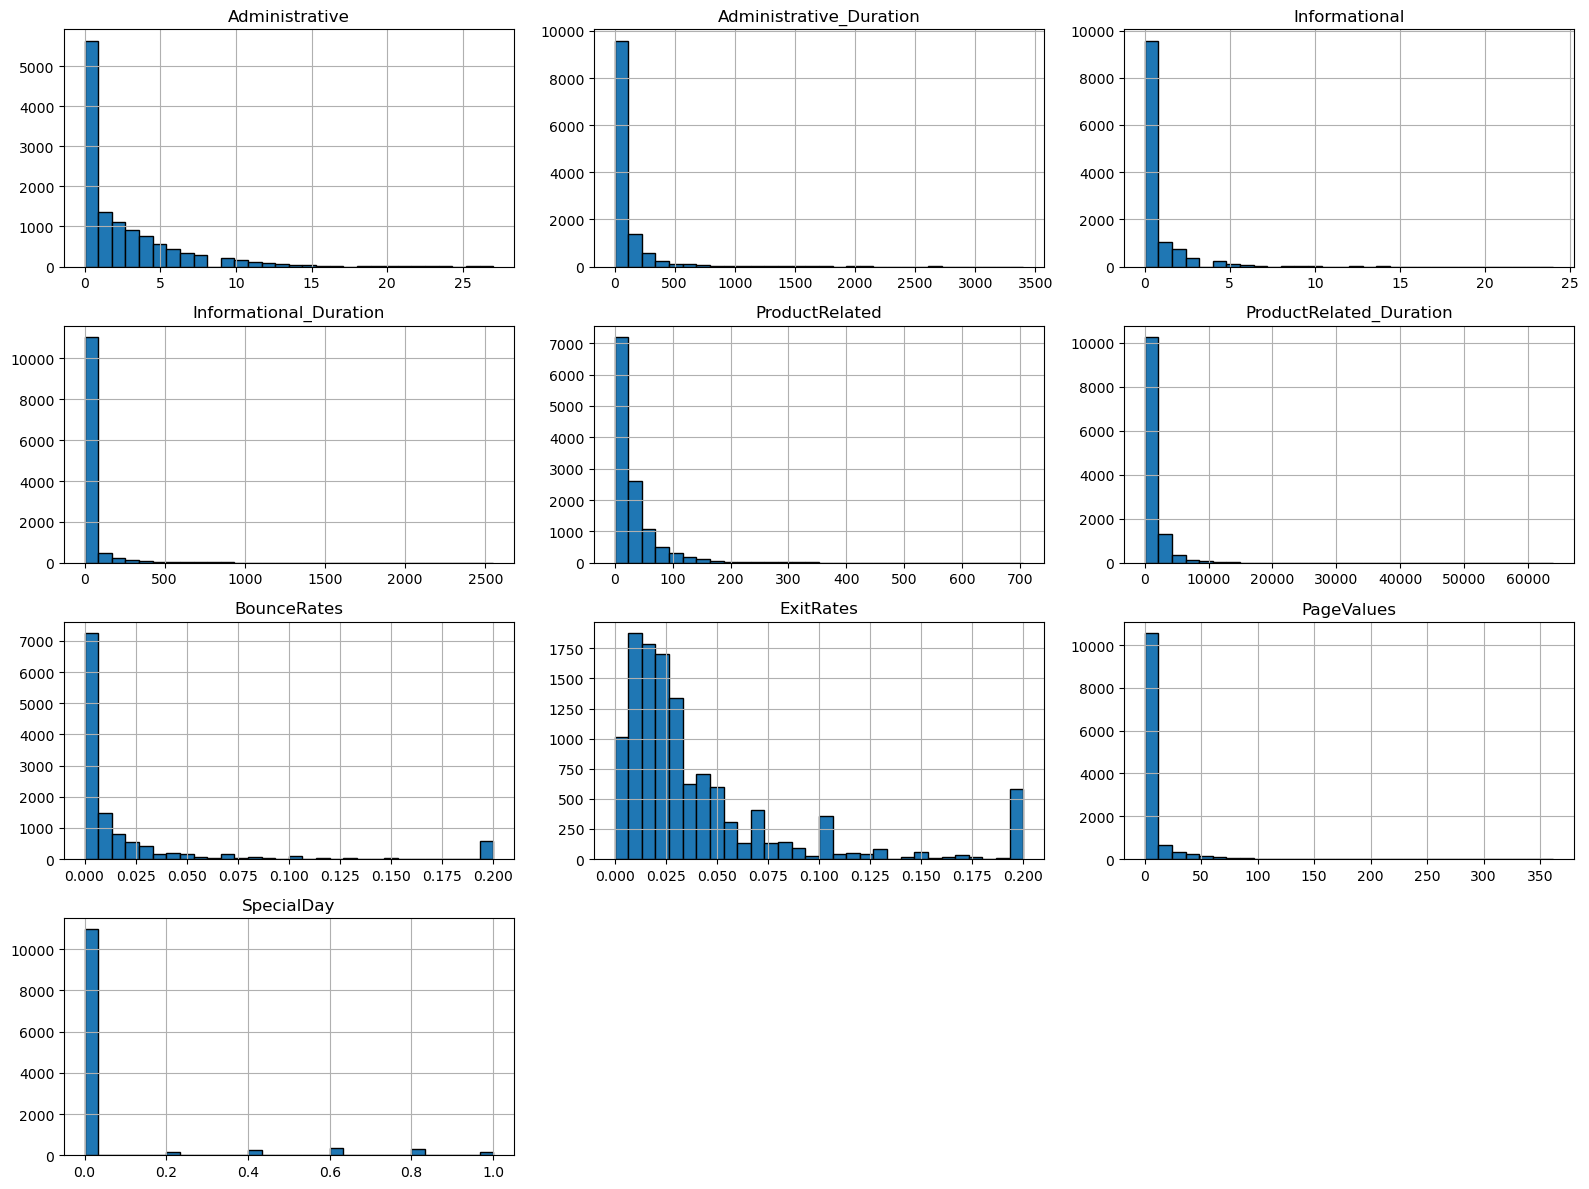

In [ ]:
# we will apply visuals now starting from univariate analysis=studies one variable to understand distribution
# historgram 

df[numeric_cols].hist(
    bins=30,
    figsize=(16, 12),
    edgecolor='black'
)


plt.tight_layout()
plt.show()

# the y left is the rows and the x is the cols 
# insights: 
# 1) Almost all your numerical columns are strongly right-skewed.
#    Most sessions have small or zero values, while a small number of sessions have very large values
# 2) they also tells me there is possible outliers but we will only remove real outliers 
#Important !!! 
# 3) Frist as most data is small at the right side 2 things to take note,extrem large numbers can affect some models 
#    therefore we might use "np.log1p()" which compress big numbers into smaller ones while perserving the order
# 4) we also might create binary indicators later 

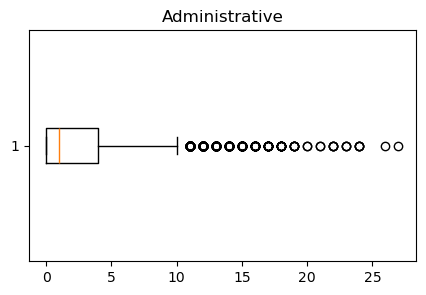

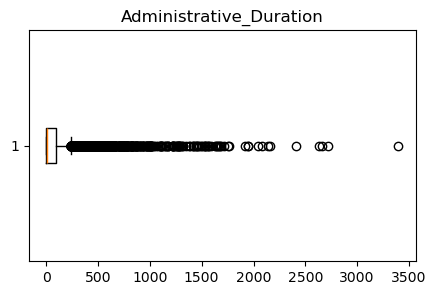

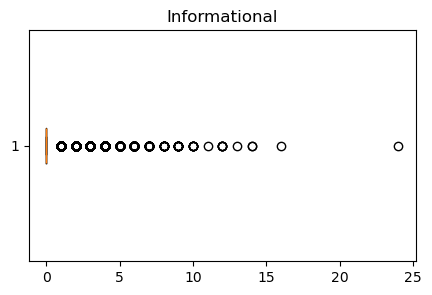

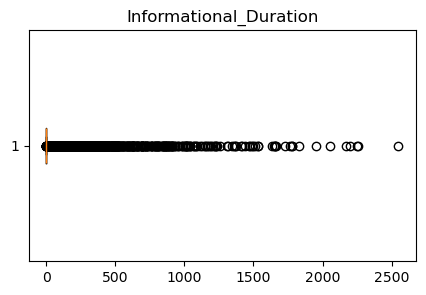

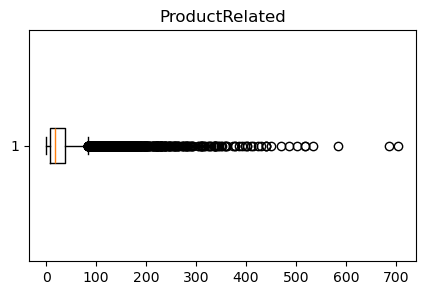

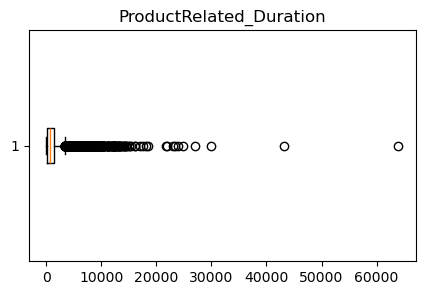

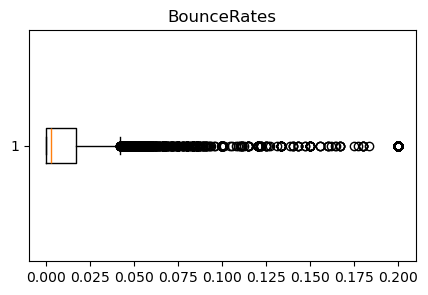

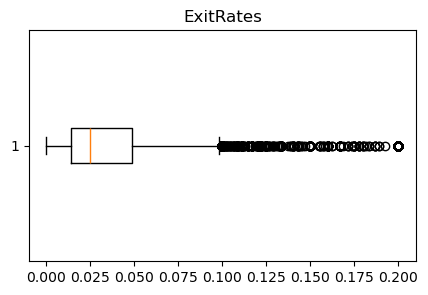

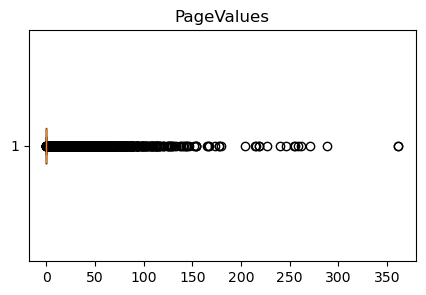

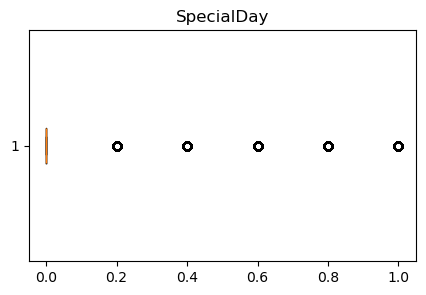

In [ ]:
# box plot

# for me to see in box plot 
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

# so at this point i had a hard time deciding if the outliers are vaild or not and also hard to see 
# so i decided to research and do a robust z score- considering my graph have outliers and my histogram is right skewed
# i will be using median,log transformation and MAD(median absolute deviation) to calculate the robust z-score
# which helps me to quickly identify outliers  

In [ ]:
def flag_log_mad_outliers(
    series,
    threshold=3.5
):
    # Create a False flag for every row initially
    flags = pd.Series(
        False,
        index=series.index
    )

    scores = pd.Series(
        np.nan,
        index=series.index,
        dtype=float
    )

    # Analyse positive values separately
    positive_values = series[
        series > 0
    ]

    # Compress the strongly skewed values
    log_values = np.log1p(
        positive_values
    )

    median = log_values.median()

    mad = (
        log_values - median
    ).abs().median()

    # Avoid dividing by zero
    if mad == 0:
        return flags, scores

    robust_z_scores = (
        0.6745
        * (log_values - median)
        / mad
    )

    # We are mainly interested in the extreme upper tail
    flags.loc[
        robust_z_scores.index
    ] = robust_z_scores > threshold

    scores.loc[
        robust_z_scores.index
    ] = robust_z_scores

    return flags, scores

pagevalue_flags, pagevalue_scores = (
    flag_log_mad_outliers(
        df['ExitRates']
    )
)

numeric_cols = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

for col in numeric_cols:

    flags, scores = flag_log_mad_outliers(df[col])

    print("=" * 60)
    print(f"{col}")
    print(f"Potential outliers: {flags.sum()}")

    display(
        df.loc[
            flags,
            [col, 'Revenue']
        ]
        .assign(Robust_Z_Score=scores[flags])
        .sort_values(
            col,
            ascending=False
        )
        .head(20)
    )

# at this part things got very confuse for me the data i got and my domain knowledge does not match but i choose to trust 
# my domain knowledge more, so my decisions is for specialDay,BounceRate,ExitRate,Pagevalues i will keep all outliers 
# this is because i dont have edvience to prove  them wrong, these data seems more like a rare case rather than outliers
# mean they can happen,just that because the others such as 0 or other numbers appeared too many times,making them look like
# outliers 
# adminstrative and infroamtion page count and the durations i will keep as they seems still reasonable to me 
# and same as just nowi do not have knowledage to clear it 


# those that i want to clear next: the product page and duration we see a 17hs and 14.5hs plus for duration which 1st i dont
# think people will use it to buy things for that long so with my knowledage i would want to remove it .Also the product page
# count anything above 450 i will also remove,as even if the user only spents 1min per page it takes 450min = 7hs plus which
# seems a little not possblie 


Administrative
Potential outliers: 0


,Administrative,Revenue,Robust_Z_Score


Administrative_Duration
Potential outliers: 0


,Administrative_Duration,Revenue,Robust_Z_Score


Informational
Potential outliers: 1


...

,ExitRates,Revenue,Robust_Z_Score
12321,0.2,False,7.793188
0,0.2,False,7.793188
2,0.2,False,7.793188
12301,0.2,False,7.793188
6,0.2,False,7.793188
7,0.2,False,7.793188
16,0.2,False,7.793188
21,0.2,False,7.793188
24,0.2,False,7.793188
11998,0.2,False,7.793188


PageValues
Potential outliers: 0


,PageValues,Revenue,Robust_Z_Score


SpecialDay
Potential outliers: 0


,SpecialDay,Revenue,Robust_Z_Score


In [ ]:
# bar char
# i already have it on the top while looking at diversity 
# i did not gain much informations from this the main things i know is that most cols have a few domain ones 

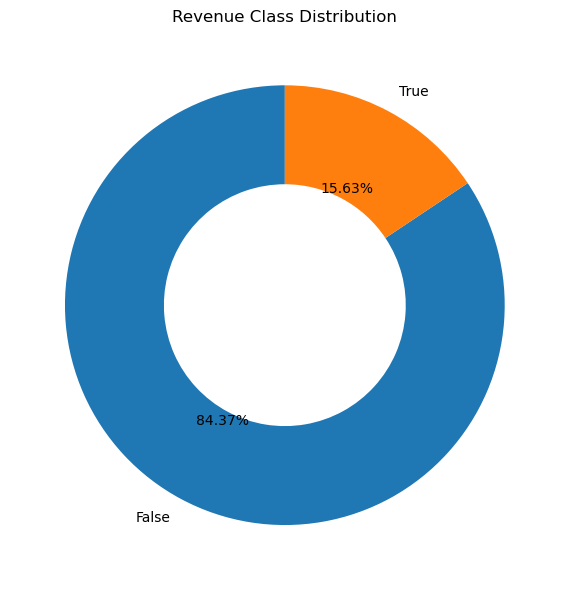

In [45]:
# same thing but now i show the percentage 
target_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    target_counts.values,
    labels=target_counts.index.astype(str),
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("Revenue Class Distribution")
plt.tight_layout()
plt.show()
# insights: i know there is this problem now this means later we have to slove it
# and accuracy might be msileading so use precision,recall,F1-score
#,precision-recall AUC,confusion matrix,balanced accuracy. 

## EDA Exploratory Data Analysis  Bivariate Analysis

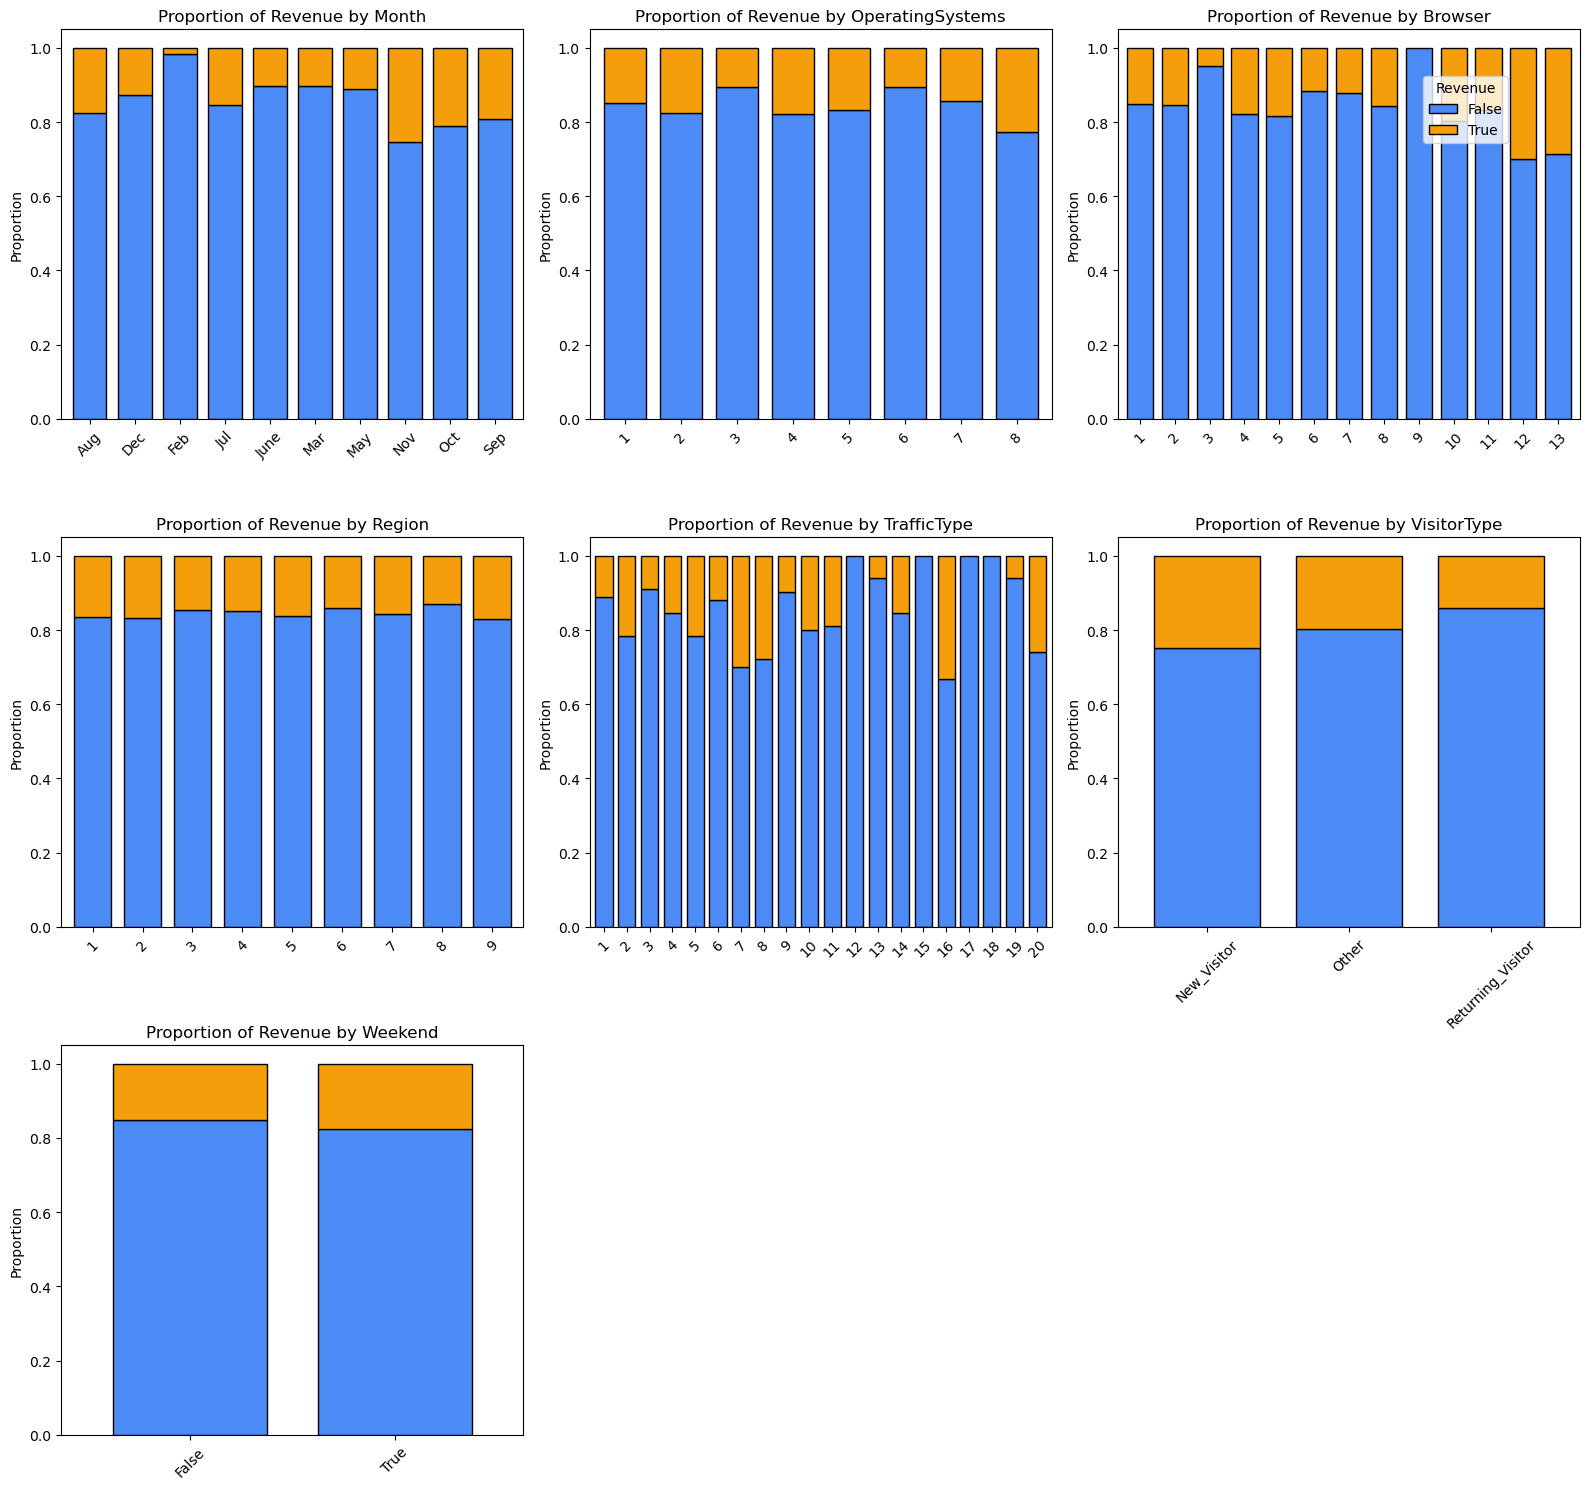

In [47]:
# 2. Set up a clean 3x3 grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 15))
axes = axes.flatten()
TARGET = "Revenue"

# 3. Calculate proportions and plot using Pandas native stacked bars
for i, col in enumerate(categorical_cols):
    # 'normalize="index"' turns the raw counts into a perfect 0.0 to 1.0 proportion
    crosstab = pd.crosstab(df[col], df[TARGET], normalize="index")

    # Plot directly as a stacked bar chart
    crosstab.plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        edgecolor="black",
        width=0.75,
        color=["#4c8bf5", "#f59e0b"], 
    )

    axes[i].set_title(f"Proportion of Revenue by {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].get_legend().remove() 

# 4. Add one single master legend so the charts aren't cluttered
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Revenue", loc="upper right", bbox_to_anchor=(0.95, 0.95))

# 5. Remove the two unused empty grid slots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# now we have a big view on the categorical cols

# 1) the visitorType,Regionand weekend seems to not being the factors affecting wheather user will buy or not 
#  but the visitor type was a little suprising the weekend affects maybe just a bit
# 2) the operating systems and the browser are both a little misleading as most people use just a few browser and os so this need to be careful
# 3) we realized that the nov has a good proprtion which might be because of 11.11 and all kinds of dues given out 
# 4) the traffic type is quite important as it tells us different users using different ways to search for items have different buy rate 

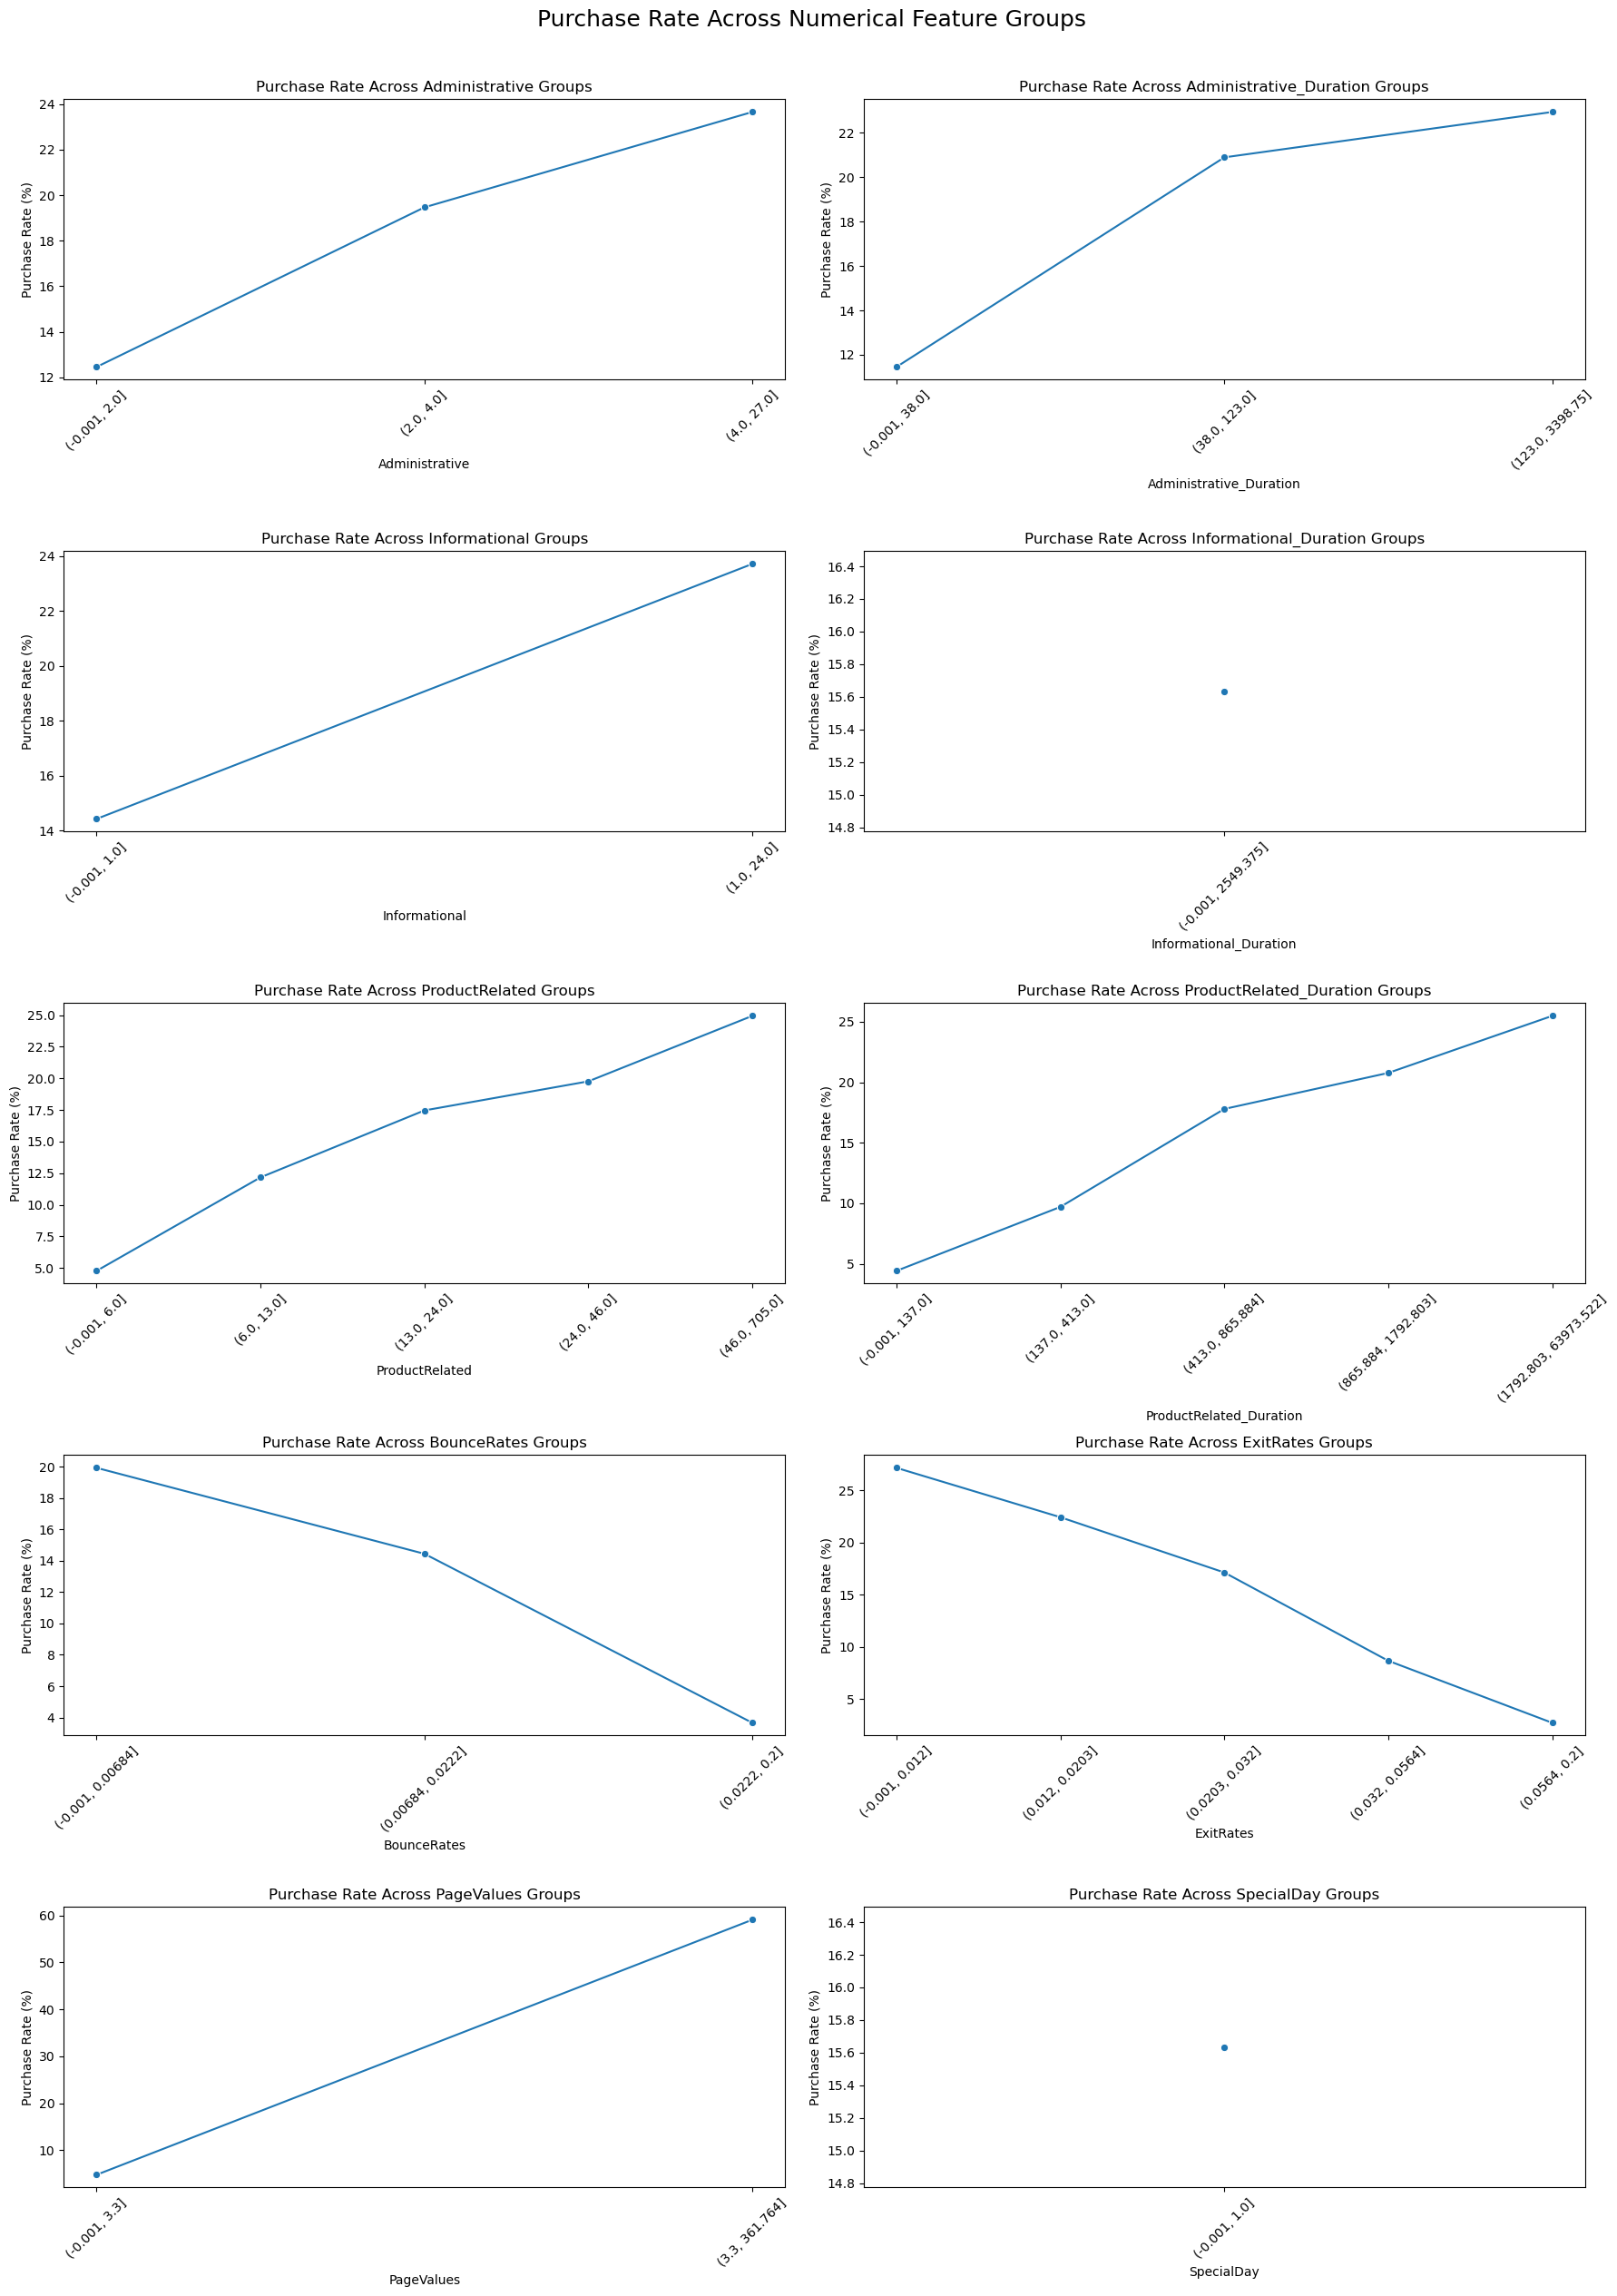

In [49]:
n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

df_plot = df.copy()
axes = axes.flatten()

for ax, feature in zip(axes, numeric_cols):

    temp = df_plot[
        [feature, TARGET]
    ].dropna().copy()

    # Check that the feature has enough different values
    if temp[feature].nunique() < 2:
        ax.text(
            0.5,
            0.5,
            "Not enough unique values",
            ha="center",
            va="center"
        )

        ax.set_title(feature)
        continue

    try:
        temp["feature_group"] = pd.qcut(
            temp[feature],
            q=5,
            duplicates="drop"
        )

        summary = (
            temp.groupby(
                "feature_group",
                observed=False
            )[TARGET]
            .agg(
                purchase_rate="mean",
                sample_size="count"
            )
            .reset_index()
        )

        summary["purchase_rate"] *= 100
        summary["group_label"] = (
            summary["feature_group"]
            .astype(str)
        )

        sns.lineplot(
            data=summary,
            x="group_label",
            y="purchase_rate",
            marker="o",
            ax=ax
        )

        ax.set_title(
            f"Purchase Rate Across {feature} Groups"
        )

        ax.set_xlabel(feature)
        ax.set_ylabel("Purchase Rate (%)")
        ax.tick_params(
            axis="x",
            rotation=45
        )

    except ValueError:

        ax.text(
            0.5,
            0.5,
            "Unable to create groups",
            ha="center",
            va="center"
        )

        ax.set_title(feature)

for ax in axes[len(numeric_cols):]:
    ax.remove()

plt.suptitle(
    "Purchase Rate Across Numerical Feature Groups",
    fontsize=18,
    y=1.01
)

plt.tight_layout()
plt.show()

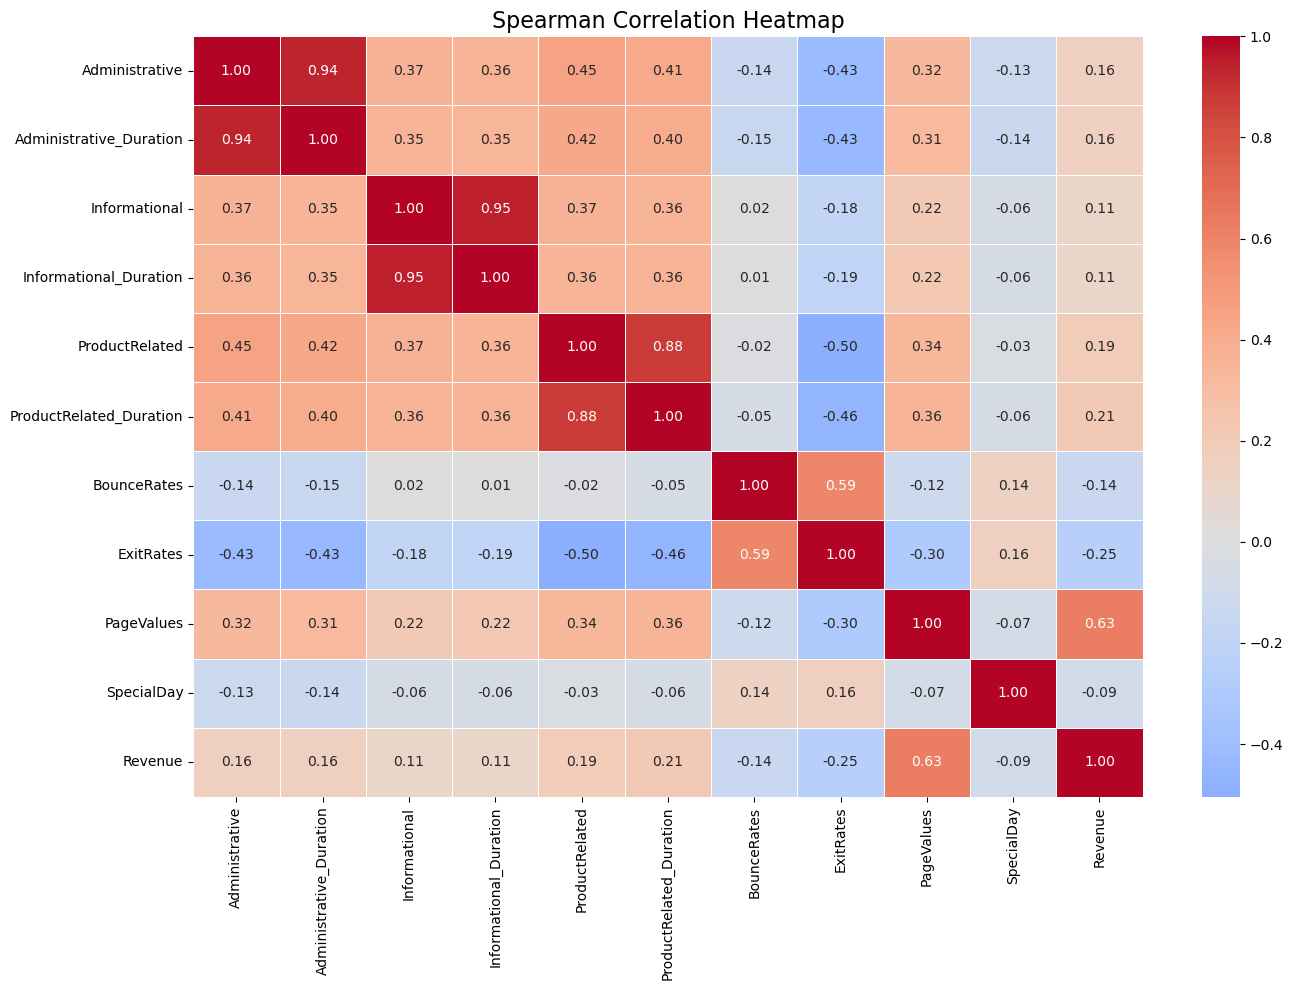

In [50]:
correlation_matrix = (
    df_plot[numeric_cols + [TARGET]]
    .corr(method="spearman")
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Spearman Correlation Heatmap",
    fontsize=16
)

plt.tight_layout()
plt.show()

##